In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Define important model parameters and variables
N_AL = 50  # number of Antennal Lobe neurons
N_ODOR_ACTIVE = 20  # how many AL neurons each odor activates
N_MB = 200  # number of Mushroom Body neurons
N_OUTPUT = 1  # single output neuron for avoidance decision
rng = np.random.default_rng(seed=123)  # for reproducibility

# Store activity history for plotting
output_history = [] 
w_mb_out_history = []

# Initialise our two odors
def make_odor(N_AL, N_ODOR_ACTIVE, seed=None):
    """
    Returns a binary vector of length n_al
    with n_active neurons set to 1.
    Each odor activates a random non-overlapping subset.
    """
    rng = np.random.default_rng(seed)
    odor = np.zeros(N_AL)
    active_indices = rng.choice(N_AL, size=N_ODOR_ACTIVE, replace=False) # Select random neurons to activate
    odor[active_indices] = 1 # Set activated neurons to 1 to create binary vector (single odor pattern)
    return odor

Odor pattern (50 neurons):
[0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0.
 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0.
 1. 0.]

Active AL neurons: [2, 3, 6, 7, 14, 15, 21, 22, 24, 26, 30, 31, 32, 33, 36, 39, 40, 41, 46, 48]

AL neuron spike times (for active neurons):
Neuron 2: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Neuron 3: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Neuron 6: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Neuron 7: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Neuron 14: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Neuron 15: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Neuron 21: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Neuron 22: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Neuron 24: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Neuron 26: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Neuron 30: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75

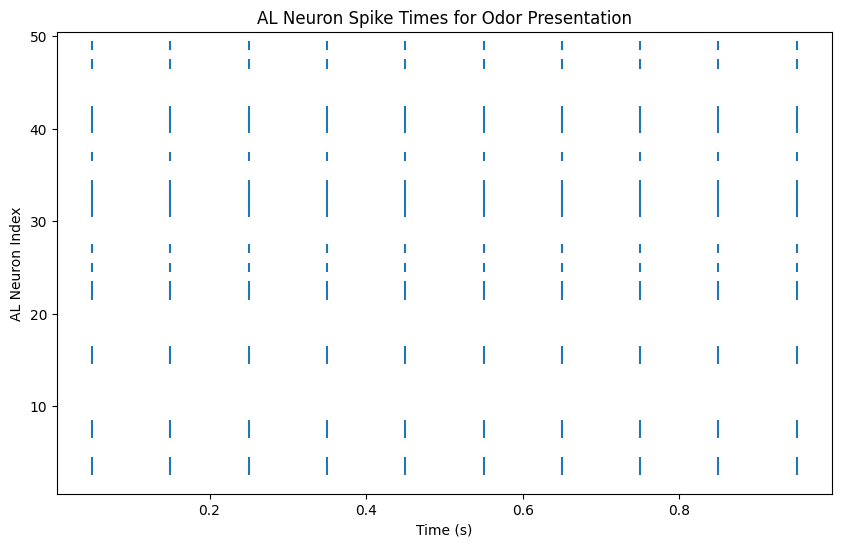

In [65]:
# AL LAYER: generate odor pattern and AL neuron spike times
odor = make_odor(N_AL, N_ODOR_ACTIVE, seed=42)

print("Odor pattern (50 neurons):")
print(odor)

dt = 0.01                     # Timestep in seconds 
t = np.arange(0,10000)*dt    # Total duration
t_total = 10000 * dt  # Total time in seconds

AL_spikes = []

for active in odor:
    if active:
        spike_times = np.arange(0.05, 1.0, 0.1)  # 10 Hz firing
    else:
        spike_times = []
    AL_spikes.append(spike_times)

active_neurons = [i for i, spike_times in enumerate(AL_spikes) if len(spike_times) > 0]
print(f"\nActive AL neurons: {active_neurons}")

print("\nAL neuron spike times (for active neurons):")
for i, spike_times in enumerate(AL_spikes):
    if len(spike_times) > 0:
        print(f"Neuron {i}: {spike_times}")

plt.figure(figsize=(10, 6))
for i, spike_times in enumerate(AL_spikes):
    plt.vlines(spike_times, i + 0.5, i + 1.5)  # Plot vertical lines for spikes
plt.xlabel('Time (s)')
plt.ylabel('AL Neuron Index')
plt.title('AL Neuron Spike Times for Odor Presentation')
plt.ylim(0.5, N_AL + 0.5)
plt.show()

In [ ]:
# need to edit to try to get current to generate spikes in some MB neurons
def alpha_current(t, spike_times, weight, tau):
    I = np.zeros_like(t)

    for tp in spike_times:
        x = t - tp
        kernel = (x / tau) * np.exp(-x / tau)
        kernel[x < 0] = 0
        I += weight * kernel

    return I

In [83]:
def LIF(I, V, dt):
    V_rest = -84.0
    V_thresh = -25.8
    V_recov = -40.2
    V_spike = 9.5
    g_leak = 0.26
    C = 1.0

    V = np.full(len(V), V_rest)
    spikes = np.zeros(len(V))

    for k in range(1, len(V) - 1):
        dV = (-g_leak * (V[k] - V_rest) + I[k]) / C
        V[k + 1] = V[k] + dt * dV

        if V[k] >= V_thresh: # Spikes if over threshold
            V[k] = V_spike   # Current voltage is spike potential
            spikes[k] = 1      # Record spike
            V[k+1] = V_recov # Next voltage is recovery threshold

    return V, spikes

In [ ]:
tau_syn = 0.2
weights_AL_MB = np.random.rand(N_MB, N_AL)
print("Weights AL to MB", weights_AL_MB.shape)  # Print the shape of the weights matrix

# TEST TO SHOW SPIKING: I_MB = np.full((N_MB, len(t)), 15.0)
I_MB = np.zeros((N_MB, len(t)))
V_MB = np.zeros((N_MB, len(t)))
print(I_MB[100, :10])  # Print the first 10 time steps for the 100th MB neuron
spikes_MB = np.zeros((N_MB, len(t)))

for n in range(N_MB):
    for j in range(N_AL):
        I_MB[n] += alpha_current(t, AL_spikes[j], weights_AL_MB[n, j], tau_syn)
    
    print(I_MB[n, :10])  # Print the first 10 time steps of the synaptic current for the nth MB neuron
    V_MB[n], spikes_MB[n] = LIF(I_MB[n], V_MB[n], dt)

Weights AL to MB (200, 50)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.         0.         0.         0.         0.         0.
 0.57225117 1.08868431 1.55338282 1.9701646 ]
[0.         0.         0.         0.         0.         0.
 0.57588084 1.09558961 1.56323561 1.98266094]
[0.         0.         0.         0.         0.         0.
 0.53659515 1.02085019 1.45659411 1.84740691]
[0.         0.         0.         0.         0.         0.
 0.40309891 0.76687908 1.09421692 1.38780178]
[0.         0.         0.         0.         0.         0.
 0.56780063 1.08021734 1.54130177 1.95484213]
[0.         0.         0.         0.         0.         0.
 0.51845513 0.98633955 1.4073528  1.78495386]
[0.         0.         0.         0.         0.         0.
 0.44174417 0.84040011 1.19911997 1.52085094]
[0.         0.         0.         0.         0.         0.
 0.38476888 0.73200695 1.04445983 1.32469456]
[0.         0.         0.         0.         0.         0.
 0.49757976 0.94662501 1.35068635 1.713083

In [94]:
print(np.unique((spikes_MB)))  # Print the first 100 time steps for the first 10 MB neurons

[0.]


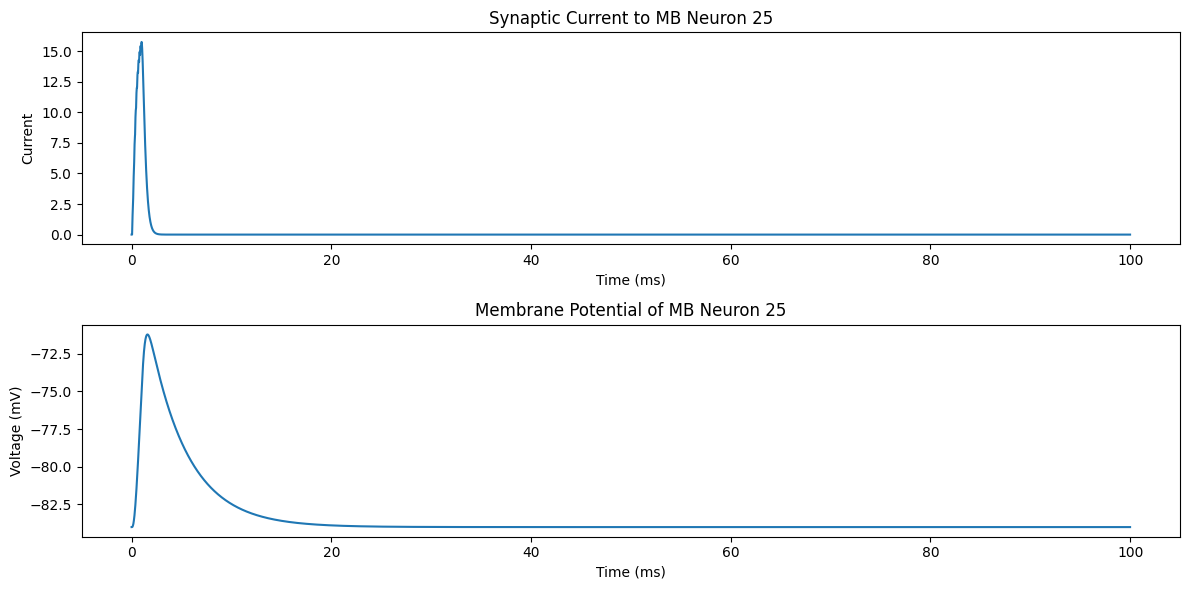

In [ ]:
mb_id = 25 # Select an MB neuron to plot

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, I_MB[mb_id])
plt.title(f"Synaptic Current to MB Neuron {mb_id}")
plt.xlabel("Time (ms)")
plt.ylabel("Current")

plt.subplot(2, 1, 2)
plt.plot(t, V_MB[mb_id])
plt.title(f"Membrane Potential of MB Neuron {mb_id}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")

plt.tight_layout()
plt.show()